# Scan 8 Analysis

Connect everything I've done so far into one start-to-finish analysis of source size




In [1]:
from skimage.transform import iradon
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable

import Methods as m
import importlib
importlib.reload(m)


<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 1 - PET/Code/Methods.py'>

### Reading Data + reconstruction

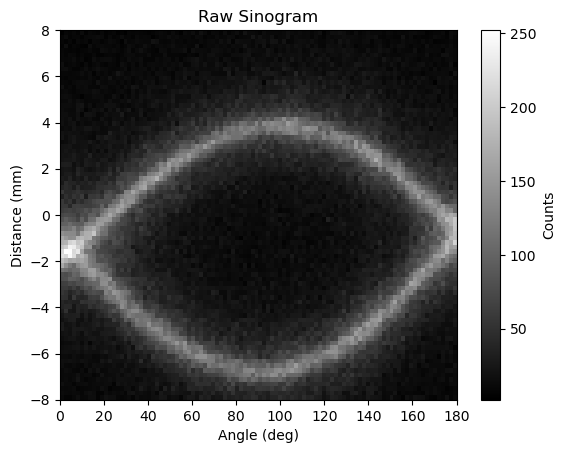

In [2]:
directory = "./data/Measurement 2026-02-13 1mm Lead"
savename = "Feb 13"
countArr, uCountArr, distance, angles = m.readSinogram(directory)


angles = angles + 180
m.display_raw_sinogram(countArr, distance, angles, "paperAnalysis/" + savename + " sinogram")

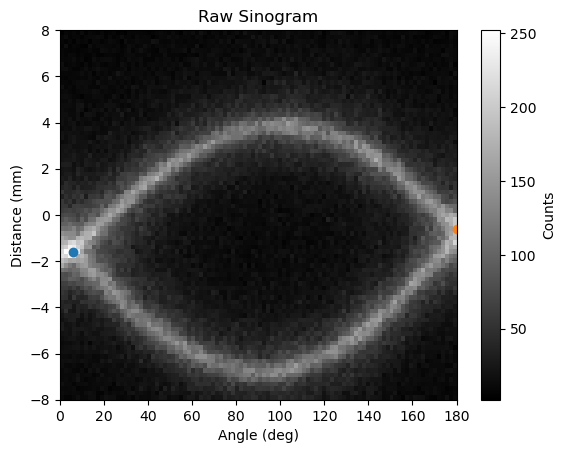

In [10]:
LCross = (6,-1.6)
RCross = (180,-0.6)


plt.figure()
plt.scatter(*LCross)
plt.scatter(*RCross)
plt.imshow(countArr, origin="lower", aspect="auto", extent=[angles[0], angles[-1], distance[0], distance[-1]], cmap="gray")
plt.title("Raw Sinogram")
plt.xlabel("Angle (deg)")
plt.ylabel("Distance (mm)")
plt.colorbar(label="Counts")
plt.show()

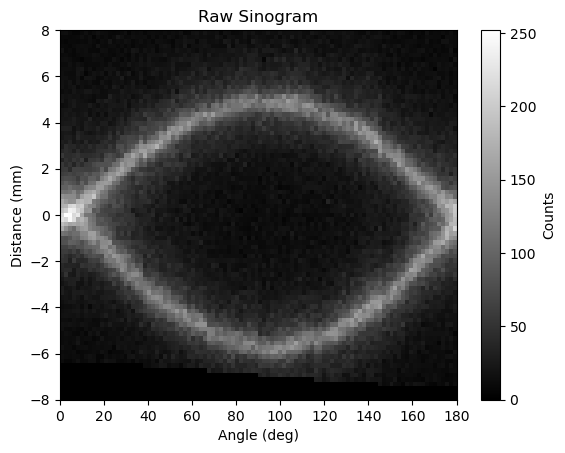

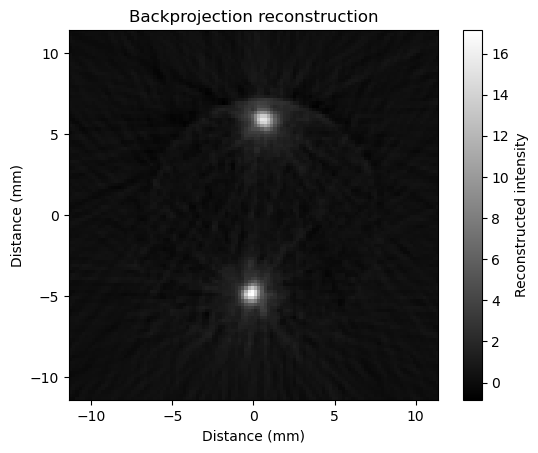

In [11]:
xMid = 0.5*(LCross[1] + RCross[1])
cosShift = (LCross[1] - RCross[1])/2
xStep = distance[1] - distance[0]

xShiftcos = - cosShift * np.cos(np.radians(angles)) - xMid
xShiftcosPixels =  np.round(xShiftcos / xStep).astype(int)

shiftedCounts = np.zeros_like(countArr)
uShiftedCounts = np.zeros_like(uCountArr)

# print(xShiftcosPixels)

for j, s in enumerate(xShiftcosPixels):
    if s > 0:
        shiftedCounts[s:, j] = countArr[:-s, j]
        uShiftedCounts[s:, j] = uCountArr[:-s, j]
    elif s < 0:
        shiftedCounts[:s, j] = countArr[-s:, j]
        uShiftedCounts[:s, j] = uCountArr[-s:, j]
    elif s == 0:
        shiftedCounts[:,j] = countArr[:,j]
        uShiftedCounts[:,j] = uCountArr[:,j]


m.display_raw_sinogram(shiftedCounts, distance, angles, "paperAnalysis/" + savename + " sinogram - shifted")
recon = iradon(shiftedCounts, theta=angles, output_size=int(len(distance) * np.sqrt(2)), filter_name="cosine", circle=False)

dimx, dimy = recon.shape # dims are the same since it has to be square
total_physical_width = dimx * (distance[1]- distance[0])
half_width = total_physical_width / 2
recon_distance = np.linspace(-half_width, half_width, dimx)

m.display_reconstructed_image(recon, recon_distance, "paperAnalysis/" + savename + " reconstruction - corrected")

### Fitting double 2D Gaussian

In [12]:
x, y = np.meshgrid(recon_distance, recon_distance)
position = np.vstack((x.ravel(), y.ravel()))
ydata = recon.ravel()
initial_guess = [1000, 0, 5, 2, 2, 1000, 0, -5, 2, 2, 0.1]
# (a1, x1, y1, sx1, sy1, a2, x2, y2, sx2, sy2, offset)

popt, pcov = curve_fit(m.double_gaussian_2d, position, ydata, p0=initial_guess)


In [13]:
y_fit_flat = m.double_gaussian_2d(position, *popt)
# a1, x1, y1, sx1, sy1, a2, x2, y2, sx2, sy2, offset = popt
x1, y1 = popt[1], popt[2]
x2, y2 = popt[6], popt[7]

sx1, sy1 = popt[3], popt[4]
sx2, sy2 = popt[8], popt[9]
usx1, usy1 = pcov[3][3], pcov[4][4]
usx2, usy2 = pcov[8][8], pcov[9][9]

r1 = np.sqrt(sx1**2 + sy1**2)
r2 = np.sqrt(sx2**2 + sy2**2)
# ur1 = r1 * np.sqrt(usx1**2 * 2 + usy1**2 * 2)
# ur2 = r2 * np.sqrt(usx2**2 * 2 + usy2**2 * 2)
ur1 = np.sqrt(((sx1/r1)**2 * usx1) + ((sy1/r1)**2 * usy1))
ur2 = np.sqrt(((sx2/r2)**2 * usx2) + ((sy2/r2)**2 * usy2))


dx = x1 - x2
dy = y1 - y2


D = np.sqrt((dx)**2 + (dy)**2)

term_x1 = (dx / D)**2 * usx1
term_x2 = (dx / D)**2 * usx2
term_y1 = (dy / D)**2 * usy1
term_y2 = (dy / D)**2 * usy2

uD = np.sqrt(term_x1 + term_x2 + term_y1 + term_y2)


precision1 = -int(math.floor(math.log10(abs(ur1))))
precision2 = -int(math.floor(math.log10(abs(ur2))))
precision3 = -int(math.floor(math.log10(abs(uD))))

print(f"r1 = {r1:.{precision1}f} +/- {ur1:.{precision1}f}")
print(f"r2 = {r2:.{precision2}f} +/- {ur2:.{precision2}f}")
print(f"D = {D:.{precision3}f} +/- {uD:.{precision3}f}")

r1 = 0.912 +/- 0.005
r2 = 0.758 +/- 0.004
D = 10.831 +/- 0.006


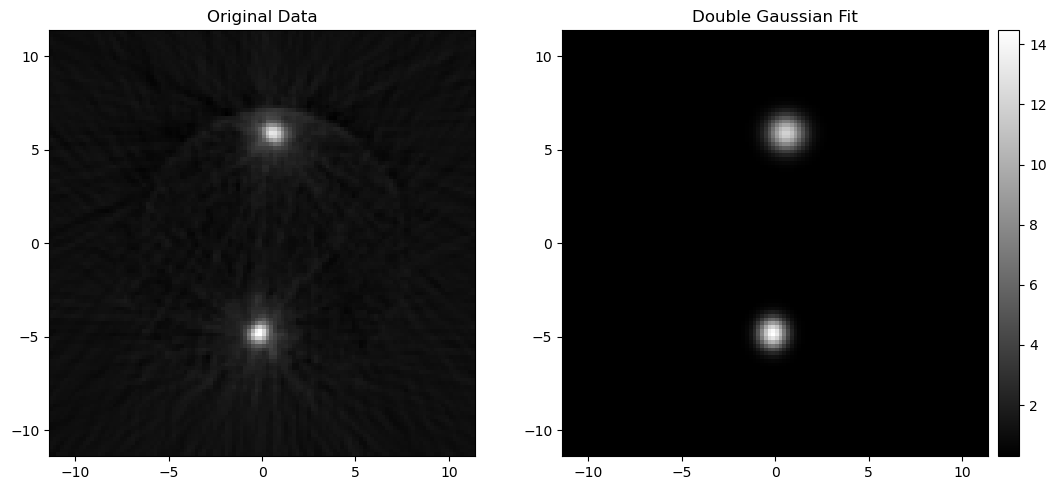

In [14]:

fit_image = y_fit_flat.reshape(recon_distance.size, recon_distance.size)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# Plot Original Data
im0 = ax[0].imshow(recon, origin="lower",extent=[
            recon_distance[0], recon_distance[-1],
            recon_distance[0], recon_distance[-1]],
        cmap="gray")
ax[0].set_title("Original Data")

# Plot the Fit
im1 = ax[1].imshow(fit_image, origin="lower", extent=[
            recon_distance[0], recon_distance[-1],
            recon_distance[0], recon_distance[-1]],
        cmap="gray")
ax[1].set_title("Double Gaussian Fit")

divider = make_axes_locatable(ax[1])
# 2. Append an axis for the colorbar on the right, 5% width, with 0.1 padding
cax = divider.append_axes("right", size="5%", pad=0.1)
# 3. Create the colorbar in that specific axis
plt.colorbar(im1, cax=cax)


plt.tight_layout()
plt.savefig("figures/paperAnalysis/" + savename + " double 2D Gaussian Fit of reconstruction")
plt.show()